## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Relationship Between Features

### Revenue and Sustainability Score
Companies with higher revenue generally have better sustainability scores because they can invest more in sustainable technologies.

### Net Profit Margin and Sustainability Score
Higher profitability enables companies to spend more on environmental and social initiatives.

### Investment in R&D and Innovation Index
Higher research investment generally leads to greater innovation.

### Innovation Index and Sustainability Score
Innovative companies usually perform better in sustainability due to improved technologies.

### Energy Efficiency and Sustainability Score
Higher energy efficiency contributes positively to sustainability performance.

### Renewable Energy Share and Sustainability Score
Greater use of renewable energy improves the overall sustainability score.

### Carbon Offset and Sustainability Score
Companies with higher carbon offset activities generally achieve higher sustainability scores.

### Emissions Intensity and Sustainability Score
Emissions intensity has a negative relationship with sustainability. Lower emissions generally indicate better sustainability.

### Waste Management Score and Sustainability Score
Efficient waste management positively contributes to sustainability.

### Employee Satisfaction and Sustainability Score
Organizations with satisfied employees often demonstrate stronger overall organizational performance.

### Community Development Investment and Sustainability Score
Higher investment in community welfare positively affects sustainability.

### Workforce Diversity and Innovation
A diverse workforce encourages innovation and better decision-making.

### Sustainability Certification and Sustainability Score
Certified companies generally follow better environmental practices and achieve higher sustainability scores.

In [2]:
df=pd.read_csv(r"C:\Users\rishi\Downloads\sustainable_power_evaluation.csv")
df.head()

,Company_ID,Revenue (USD),Net Profit Margin (%),Investment in R&D (%),Market Share (%),Debt-to-Equity Ratio,Energy Efficiency (%),Smart Grid Implementation Score,Innovation Index,Digitalization Level (%),Carbon Offset (tons/year),Renewable Energy Share (%),Emissions Intensity (kg CO₂ per MWh),Waste Management Score,Employee Satisfaction Score,Community Development Investment (USD),Workforce Diversity Index,Sustainability Certification,Sustainability Score
0,C1,3.751656e+09,5.553988,5.972408,13.486790,1.758788,69.681776,0.0,41.510718,95.413164,4226.127791,49.885102,126.289249,4.027536,1.126979,2.123090e+06,0.134297,1.0,31.171122
1,C2,9.507636e+09,16.257028,5.692597,15.953960,2.435754,73.671783,0.0,NaN,22.325540,2627.159992,21.508523,NaN,NaN,0.723106,5.573337e+06,0.932630,1.0,27.887526
2,C3,7.322619e+09,26.188375,18.218837,5.084311,2.304467,92.727370,2.0,43.778148,92.230778,3457.527729,NaN,236.795811,6.954071,7.437673,7.872696e+06,0.894521,NaN,32.128801
3,C4,5.990598e+09,21.966747,5.741378,12.534995,0.546310,67.000219,4.0,23.073459,NaN,4416.748505,16.970524,107.808211,2.527427,7.118821,3.150006e+06,0.189997,0.0,19.937953
4,C5,1.568626e+09,24.196834,6.167045,11.477745,0.532823,93.482484,NaN,29.119645,98.552413,2478.585050,71.846018,269.628011,3.114056,NaN,NaN,0.343444,NaN,40.868157


# Generalization of the Dataset

- The dataset includes a balanced combination of:
  - Financial indicators (Revenue, Net Profit Margin, Debt-to-Equity Ratio)
  - Operational indicators (Energy Efficiency, Smart Grid Score, Digitalization Level)
  - Environmental indicators (Renewable Energy Share, Carbon Offset, Emissions Intensity, Waste Management Score)
  - Social indicators (Employee Satisfaction, Workforce Diversity, Community Development Investment)


Financially strong companies generally have greater resources to invest in sustainable technologies and environmental initiatives.

Environmental features such as **Energy Efficiency**, **Renewable Energy Share**, **Carbon Offset**, and **Waste Management Score** are expected to have a positive relationship with the Sustainability Score.

**Emissions Intensity** is expected to have a negative relationship with Sustainability Score because higher emissions indicate poorer environmental performance.

Innovation-related features such as **Investment in R&D**, **Innovation Index**, and **Digitalization Level** are expected to positively influence sustainability by improving operational efficiency and adopting cleaner technologies.

The dataset combines multiple dimensions of sustainability, making it suitable for analyzing the factors that influence a company's overall sustainability performance.

After preprocessing, including missing value treatment, feature scaling, and removal of the identifier column, the dataset is clean and suitable for building an accurate Linear Regression model.

Overall, the dataset provides sufficient information to understand how financial, environmental, operational, and social factors collectively affect the Sustainability Score of companies.

In [3]:
print(df.shape)
print(df.info())
display(df.describe())
print(df.isnull().sum())

(1000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Company_ID                              1000 non-null   object 
 1   Revenue (USD)                           900 non-null    float64
 2   Net Profit Margin (%)                   900 non-null    float64
 3   Investment in R&D (%)                   900 non-null    float64
 4   Market Share (%)                        900 non-null    float64
 5   Debt-to-Equity Ratio                    900 non-null    float64
 6   Energy Efficiency (%)                   900 non-null    float64
 7   Smart Grid Implementation Score         900 non-null    float64
 8   Innovation Index                        900 non-null    float64
 9   Digitalization Level (%)                900 non-null    float64
 10  Carbon Offset (tons/year)               900 non-nu

,Revenue (USD),Net Profit Margin (%),Investment in R&D (%),Market Share (%),Debt-to-Equity Ratio,Energy Efficiency (%),Smart Grid Implementation Score,Innovation Index,Digitalization Level (%),Carbon Offset (tons/year),Renewable Energy Share (%),Emissions Intensity (kg CO₂ per MWh),Waste Management Score,Employee Satisfaction Score,Community Development Investment (USD),Workforce Diversity Index,Sustainability Certification,Sustainability Score
count,9.000000e+02,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,9.000000e+02,900.000000,900.000000,900.000000
mean,4.878053e+09,15.343636,10.559490,9.917403,1.536841,74.744860,5.092222,49.022424,48.329844,2433.617518,50.485534,453.233222,4.893243,4.886492,4.991378e+06,0.497934,0.522222,34.090427
std,2.925279e+09,8.741117,5.496283,5.677045,0.826742,14.466155,3.148767,28.680584,28.797507,1399.643772,29.197972,201.271799,2.915853,2.893455,2.970724e+06,0.289075,0.499784,7.412632
min,5.627391e+07,0.096548,1.000221,0.113002,0.100089,50.309191,0.000000,0.024100,0.024293,0.264135,0.024087,101.718211,0.001577,0.013336,2.723097e+04,0.000310,0.000000,13.055051
25%,2.283477e+09,7.450304,6.151952,5.042797,0.830363,62.224506,2.000000,24.150153,23.152442,1279.710530,24.491251,286.613647,2.324381,2.355631,2.394831e+06,0.240344,0.000000,28.929307
50%,4.954609e+09,15.582836,10.595023,9.785289,1.547229,74.184384,5.000000,48.238991,46.406530,2405.150300,51.136608,451.180233,4.845605,4.751894,4.917088e+06,0.502868,1.000000,34.219957
75%,7.378626e+09,22.884210,15.417837,14.823284,2.241159,86.885505,8.000000,73.008659,72.222261,3602.676783,75.896725,630.605270,7.514962,7.281004,7.709247e+06,0.748238,1.000000,39.349145
max,9.997180e+09,29.982412,19.958596,19.991198,2.993473,99.967515,10.000000,99.920730,99.601278,4993.086596,99.950519,799.534586,9.986985,9.988448,9.958606e+06,0.999925,1.000000,53.476889


Company_ID                                  0
Revenue (USD)                             100
Net Profit Margin (%)                     100
Investment in R&D (%)                     100
Market Share (%)                          100
Debt-to-Equity Ratio                      100
Energy Efficiency (%)                     100
Smart Grid Implementation Score           100
Innovation Index                          100
Digitalization Level (%)                  100
Carbon Offset (tons/year)                 100
Renewable Energy Share (%)                100
Emissions Intensity (kg CO₂ per MWh)      100
Waste Management Score                    100
Employee Satisfaction Score               100
Community Development Investment (USD)    100
Workforce Diversity Index                 100
Sustainability Certification              100
Sustainability Score                      100
dtype: int64


## Handle Missing Values

In [4]:
if 'Company_ID' in df.columns:
    features=df.drop(columns=['Company_ID'])
else:
    features=df.copy()
num_cols=features.select_dtypes(include=np.number).columns
imp=SimpleImputer(strategy='mean')
features[num_cols]=imp.fit_transform(features[num_cols])
df[features.columns]=features
print(df.isnull().sum())

Company_ID                                0
Revenue (USD)                             0
Net Profit Margin (%)                     0
Investment in R&D (%)                     0
Market Share (%)                          0
Debt-to-Equity Ratio                      0
Energy Efficiency (%)                     0
Smart Grid Implementation Score           0
Innovation Index                          0
Digitalization Level (%)                  0
Carbon Offset (tons/year)                 0
Renewable Energy Share (%)                0
Emissions Intensity (kg CO₂ per MWh)      0
Waste Management Score                    0
Employee Satisfaction Score               0
Community Development Investment (USD)    0
Workforce Diversity Index                 0
Sustainability Certification              0
Sustainability Score                      0
dtype: int64


## Visualizations

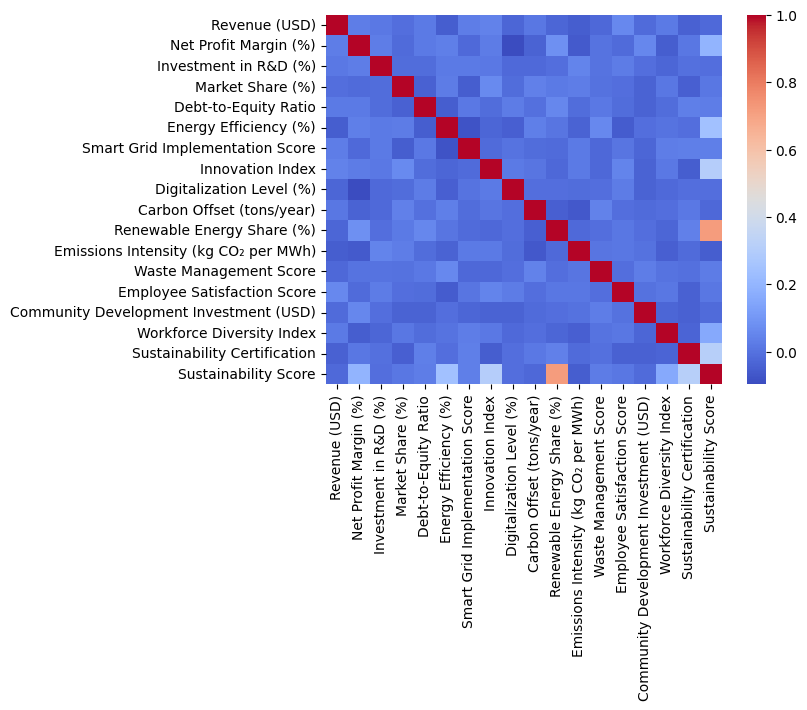

C:\Users\rishi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


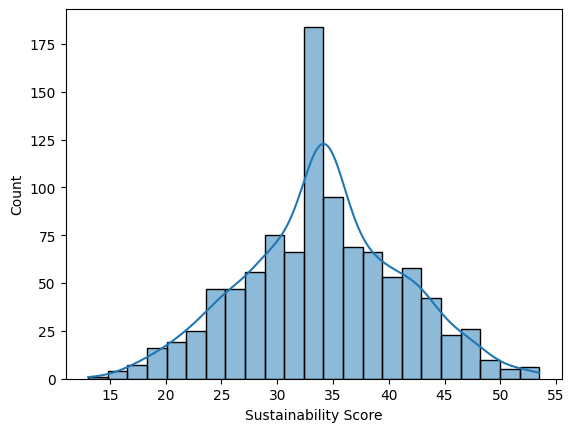

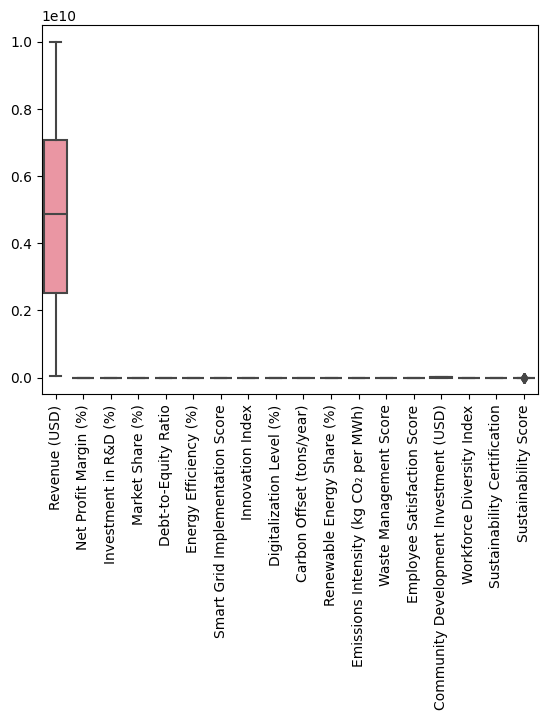

In [5]:
sns.heatmap(df.select_dtypes(include=np.number).corr(),cmap='coolwarm')
plt.show()
sns.histplot(df['Sustainability Score'],kde=True)
plt.show()
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

In [6]:
if 'Company_ID' in df.columns:
    df=df.drop(columns=['Company_ID'])
cat=df.select_dtypes(include='object').columns
if len(cat)>0:
    df=pd.get_dummies(df,columns=cat,drop_first=True)
X=df.drop(columns=['Sustainability Score'])
y=df['Sustainability Score']
scaler=StandardScaler()
X=pd.DataFrame(scaler.fit_transform(X),columns=X.columns)

## Train Test Split

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Regression Models

In [8]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

prediction_df = pd.DataFrame({
    'Actual Sustainability Score': y_test.values,
    'Predicted Sustainability Score': y_pred
})

prediction_df.head(20)

,Actual Sustainability Score,Predicted Sustainability Score
0,45.079879,43.885999
1,34.090427,38.669079
2,38.999840,37.833163
3,30.791824,30.955562
4,24.719730,32.180181
5,35.273889,35.229658
6,29.907934,30.918227
7,36.491725,35.764886
8,39.059972,38.268430
9,48.841837,48.001847


## Insights
- Company_ID is removed because it is an identifier.
- Mean imputation preserves all observations.
- StandardScaler normalizes numeric features.
- Correlation heatmap helps identify relationships.
- Compare models using MAE, MSE, RMSE, and R².
- Higher R² and lower error metrics indicate a better model.

In [9]:
models={
'Linear Regression':LinearRegression(),
}
results=[]
for n,m in models.items():
    m.fit(X_train,y_train)
    p=m.predict(X_test)
    results.append([n,
                    mean_absolute_error(y_test,p),
                    mean_squared_error(y_test,p),
                    np.sqrt(mean_squared_error(y_test,p)),
                    r2_score(y_test,p)])
res=pd.DataFrame(results,columns=['Model','MAE','MSE','RMSE','R2'])
display(res)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,1.913319,8.819387,2.969745,0.816426


# Overall Analysis

- The dataset mainly consists of numerical features, making it suitable for Linear Regression.
- Environmental variables such as Energy Efficiency, Renewable Energy Share, Carbon Offset, and Waste Management Score are expected to positively influence Sustainability Score.
- Emissions Intensity is expected to have a negative impact on Sustainability Score.
- Financial indicators like Revenue and Net Profit Margin indirectly support sustainability by enabling investments in green technologies.
- The dataset combines financial, operational, environmental, and social indicators, providing a comprehensive evaluation of corporate sustainability.
- After handling missing values and scaling the numerical features, the dataset becomes suitable for building a Linear Regression model.